# Gene-grouped nested cross-validation (XGBoost)

**Stage 1 of 2 — honest performance only.**  
Do not take a single deploy config from this notebook: each outer fold has its own
`θ*`, tree budget, and threshold. Stage 2 (`notebooks/train_final_xgboost.ipynb`)
runs a **separate single-loop gene CV** on all labelled data to pick one production
setting, then fits on every labelled row.

Logic: `src/cv_train_eval.py` (folds + nested tune/fit) and shared helpers in
`src/features.py` (features, matrices, `fit_predict`).

Outer folds estimate generalization. Inner CV on the remaining folds selects
**hyperparameters and boosting rounds** (median `best_iteration+1` from inner
early stopping). The outer refit trains on that fold’s **full pool** with fixed
`n_estimators` — no outer early-stopping holdout.


In [1]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)


In [2]:
load_dotenv()
project_root = Path(os.environ["PROJECT_ROOT"])
sys.path.insert(0, str(project_root / "src"))

from cv_train_eval import (
    PARAM_DISTRIBUTIONS,
    run_cv_folds,
    run_nested_cv,
)
from features import FEATURE_COLUMNS, GROUP_COLUMN, split_summary

N_FOLDS = 5
SEED = 42
N_TUNING_TRIALS = 12
MODELS_DIR = project_root / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("features:", FEATURE_COLUMNS)


features: ['protein_position', 'relative_protein_position', 'distance_to_closest_feature', 'has_protein_position', 'in_domain', 'in_region', 'in_zinc_finger', 'in_active_site', 'in_binding_site', 'in_disulfide', 'in_mod_res', 'in_functional_site', 'in_any_feature', 'closest_feature_type', 'ReferenceAlleleVCF', 'AlternateAlleleVCF']


## Assign CV folds

`run_cv_folds()` → `data/processed/cv_folds.parquet` (same as `python src/cv_train_eval.py`).


In [3]:
folded = run_cv_folds(n_folds=N_FOLDS, seed=SEED)
display(split_summary(folded, partition_col="fold"))

gene_folds = folded.groupby(GROUP_COLUMN)["fold"].nunique()
assert (gene_folds == 1).all()
print(
    f"{folded[GROUP_COLUMN].nunique()} genes, {len(folded)} variants, "
    "gene overlap across folds: none"
)


,fold,n_variants,n_genes,pct_pathogenic,pct_with_protein_position
0,0,2313,19,35.538262,77.086035
1,1,2313,26,41.980112,74.189364
2,2,2313,31,52.053610,76.394293
3,3,2312,30,74.134948,80.449827
4,4,2312,31,70.977509,81.833910


137 genes, 11563 variants, gene overlap across folds: none


## Nested CV: tune θ, n_estimators, and decision threshold

`run_nested_cv()` (chosen on the outer-train pool only):

1. Each fit uses `scale_pos_weight = n_benign / n_pathogenic` on that train set
2. Inner CV picks hyperparameters and tree budget (early stopping)
3. Probability cutoff = **median of per-inner-fold** Youden (or F1) thresholds — not pooled scores
4. Refit on the full pool; apply that cutoff on the outer test fold

Default cutoff is **Youden's J**. Plain F1 on path-heavy folds often picks a near-zero
threshold and predicts almost everything pathogenic.


In [4]:
THRESHOLD_METHOD = "youden"  # balanced TPR−FPR; alt: "f1" (tends toward all-pathogenic)

cv_result = run_nested_cv(
    folded,
    n_folds=N_FOLDS,
    n_trials=N_TUNING_TRIALS,
    seed=SEED,
    param_distributions=PARAM_DISTRIBUTIONS,
    threshold_method=THRESHOLD_METHOD,
)
fold_metrics = cv_result["fold_metrics"]
oof = cv_result["oof"]
tuning_log = cv_result["tuning_log"]
importance_df = cv_result["importance"]
confusion_total = cv_result["confusion_total"]
cls_summary = cv_result["classification_summary"]
fold_metrics


outer 0: thr=0.492  ROC=0.687  P=0.620  R=0.179  Acc=0.669  n_estimators=49
outer 1: thr=0.438  ROC=0.722  P=0.586  R=0.736  Acc=0.671  n_estimators=142
outer 2: thr=0.519  ROC=0.691  P=0.663  R=0.614  Acc=0.636  n_estimators=121
outer 3: thr=0.524  ROC=0.659  P=0.802  R=0.695  Acc=0.647  n_estimators=73
outer 4: thr=0.516  ROC=0.651  P=0.812  R=0.662  Acc=0.651  n_estimators=38


,n_train,n_test,n_test_genes,best_inner_roc_auc,n_estimators,threshold,roc_auc,pr_auc,accuracy,precision,...,tn,fp,fn,tp,param_subsample,param_reg_lambda,param_min_child_weight,param_max_depth,param_learning_rate,param_colsample_bytree
fold,,,,,,,,,,,,,,,,,,,,,
0,9250,2313,19,0.666780,49,0.492410,0.687319,0.540177,0.669261,0.620253,...,1401,90,675,147,0.9,1.0,5,3,0.10,0.8
1,9250,2313,26,0.641405,142,0.437649,0.721884,0.644841,0.670990,0.586066,...,837,505,256,715,0.8,1.0,1,6,0.03,0.9
2,9250,2313,31,0.642887,121,0.519299,0.691481,0.672111,0.636403,0.662780,...,733,376,465,739,0.7,0.5,10,6,0.05,0.9
3,9251,2312,30,0.673337,73,0.523603,0.659093,0.839653,0.647059,0.802153,...,304,294,522,1192,0.9,1.0,5,4,0.10,0.7
4,9251,2312,31,0.659125,38,0.515609,0.650898,0.794590,0.650952,0.811659,...,419,252,555,1086,0.9,5.0,5,3,0.10,0.7


## Chosen hyperparameters per outer fold

Each outer fold has its own `θ*_k` from **inner CV mean AUC**.


In [5]:
param_cols = [c for c in fold_metrics.columns if c.startswith("param_")]
display(
    fold_metrics[
        [
            "threshold",
            "n_estimators",
            "roc_auc",
            "precision",
            "recall",
            "accuracy",
            "f1",
        ]
        + param_cols
    ].round(3)
)


,threshold,n_estimators,roc_auc,precision,recall,accuracy,f1,param_subsample,param_reg_lambda,param_min_child_weight,param_max_depth,param_learning_rate,param_colsample_bytree
fold,,,,,,,,,,,,,
0,0.492,49,0.687,0.620,0.179,0.669,0.278,0.9,1.0,5,3,0.10,0.8
1,0.438,142,0.722,0.586,0.736,0.671,0.653,0.8,1.0,1,6,0.03,0.9
2,0.519,121,0.691,0.663,0.614,0.636,0.637,0.7,0.5,10,6,0.05,0.9
3,0.524,73,0.659,0.802,0.695,0.647,0.745,0.9,1.0,5,4,0.10,0.7
4,0.516,38,0.651,0.812,0.662,0.651,0.729,0.9,5.0,5,3,0.10,0.7


## Operating-point detail (confusion + per-fold)


,threshold,accuracy,precision,recall,f1
mean,0.498,0.655,0.697,0.577,0.608
std,0.036,0.015,0.104,0.227,0.191
min,0.438,0.636,0.586,0.179,0.278
max,0.524,0.671,0.812,0.736,0.745


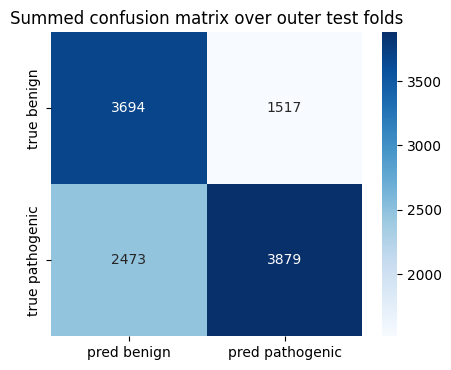

,threshold,roc_auc,pr_auc,precision,recall,accuracy,f1,tn,fp,fn,tp
fold,,,,,,,,,,,
0,0.492,0.687,0.540,0.620,0.179,0.669,0.278,1401,90,675,147
1,0.438,0.722,0.645,0.586,0.736,0.671,0.653,837,505,256,715
2,0.519,0.691,0.672,0.663,0.614,0.636,0.637,733,376,465,739
3,0.524,0.659,0.840,0.802,0.695,0.647,0.745,304,294,522,1192
4,0.516,0.651,0.795,0.812,0.662,0.651,0.729,419,252,555,1086


In [6]:
display(cls_summary.round(3))

cm = np.array(
    [
        [confusion_total["tn"], confusion_total["fp"]],
        [confusion_total["fn"], confusion_total["tp"]],
    ]
)
fig, ax = plt.subplots(figsize=(4.5, 3.8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["pred benign", "pred pathogenic"],
    yticklabels=["true benign", "true pathogenic"],
    ax=ax,
)
ax.set_title("Summed confusion matrix over outer test folds")
fig.tight_layout()
plt.show()

display(
    fold_metrics[
        ["threshold", "roc_auc", "pr_auc", "precision", "recall", "accuracy", "f1", "tn", "fp", "fn", "tp"]
    ].round(3)
)


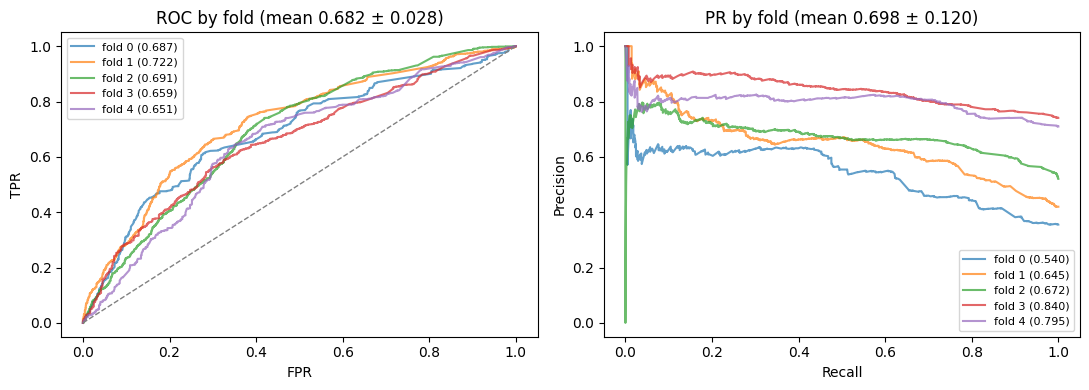

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

mean_roc = fold_metrics["roc_auc"].mean()
std_roc = fold_metrics["roc_auc"].std()
mean_pr = fold_metrics["pr_auc"].mean()
std_pr = fold_metrics["pr_auc"].std()

for fold, part in oof.groupby("fold"):
    fpr, tpr, _ = roc_curve(part["y_true"], part["y_proba"])
    axes[0].plot(
        fpr,
        tpr,
        alpha=0.7,
        label=f"fold {fold} ({roc_auc_score(part['y_true'], part['y_proba']):.3f})",
    )
    prec, rec, _ = precision_recall_curve(part["y_true"], part["y_proba"])
    axes[1].plot(
        rec,
        prec,
        alpha=0.7,
        label=f"fold {fold} ({average_precision_score(part['y_true'], part['y_proba']):.3f})",
    )

axes[0].plot([0, 1], [0, 1], ls="--", c="gray", lw=1)
axes[0].set_xlabel("FPR")
axes[0].set_ylabel("TPR")
axes[0].set_title(f"ROC by fold (mean {mean_roc:.3f} ± {std_roc:.3f})")
axes[0].legend(fontsize=8)

axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title(f"PR by fold (mean {mean_pr:.3f} ± {std_pr:.3f})")
axes[1].legend(fontsize=8)

fig.tight_layout()
plt.show()


## Feature importance across folds

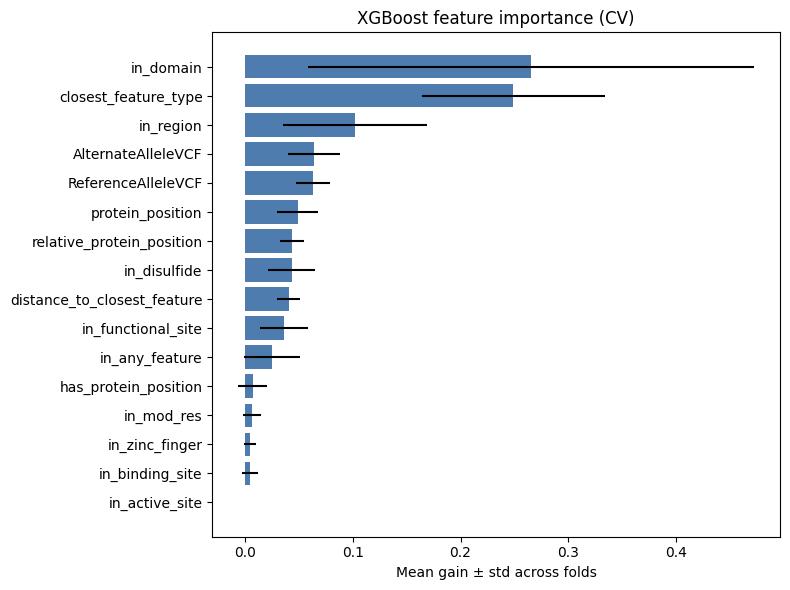

,mean,std
in_domain,0.2656,0.2074
closest_feature_type,0.2492,0.0852
in_region,0.1020,0.0667
AlternateAlleleVCF,0.0634,0.0241
ReferenceAlleleVCF,0.0628,0.0156
protein_position,0.0485,0.0187
relative_protein_position,0.0433,0.0115
in_disulfide,0.0431,0.0220
distance_to_closest_feature,0.0402,0.0103
in_functional_site,0.0359,0.0222


In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(
    importance_df.index[::-1],
    importance_df["mean"].iloc[::-1],
    xerr=importance_df["std"].iloc[::-1],
    color="#3b6ea5",
    alpha=0.9,
)
ax.set_xlabel("Mean gain ± std across folds")
ax.set_title("XGBoost feature importance (CV)")
fig.tight_layout()
plt.show()

importance_df[["mean", "std"]].round(4)


## Persist fold predictions

Per-fold test predictions are still saved for inspection; headline metrics are mean±std,
not pooled OOF ROC.


In [9]:
oof_path = MODELS_DIR / "xgb_cv_oof_predictions.parquet"
metrics_path = MODELS_DIR / "xgb_cv_fold_metrics.csv"
tuning_path = MODELS_DIR / "xgb_cv_tuning_log.csv"
oof.to_parquet(oof_path, index=False)
fold_metrics.to_csv(metrics_path)
tuning_log.to_csv(tuning_path, index=False)
print("Saved", oof_path)
print("Saved", metrics_path)
print("Saved", tuning_path)
fold_metrics.round(3)


Saved /home/milijanas/projects/clinvar-pathogenicity-classifier/models/xgb_cv_oof_predictions.parquet
Saved /home/milijanas/projects/clinvar-pathogenicity-classifier/models/xgb_cv_fold_metrics.csv
Saved /home/milijanas/projects/clinvar-pathogenicity-classifier/models/xgb_cv_tuning_log.csv


,n_train,n_test,n_test_genes,best_inner_roc_auc,n_estimators,threshold,roc_auc,pr_auc,accuracy,precision,...,tn,fp,fn,tp,param_subsample,param_reg_lambda,param_min_child_weight,param_max_depth,param_learning_rate,param_colsample_bytree
fold,,,,,,,,,,,,,,,,,,,,,
0,9250,2313,19,0.667,49,0.492,0.687,0.540,0.669,0.620,...,1401,90,675,147,0.9,1.0,5,3,0.10,0.8
1,9250,2313,26,0.641,142,0.438,0.722,0.645,0.671,0.586,...,837,505,256,715,0.8,1.0,1,6,0.03,0.9
2,9250,2313,31,0.643,121,0.519,0.691,0.672,0.636,0.663,...,733,376,465,739,0.7,0.5,10,6,0.05,0.9
3,9251,2312,30,0.673,73,0.524,0.659,0.840,0.647,0.802,...,304,294,522,1192,0.9,1.0,5,4,0.10,0.7
4,9251,2312,31,0.659,38,0.516,0.651,0.795,0.651,0.812,...,419,252,555,1086,0.9,5.0,5,3,0.10,0.7


## Conclusion — honest performance KPIs

Gene-grouped **nested** CV on held-out genes (outer mean ± std).
These are the numbers to report. Nested CV is **not** how we pick the shipped model.

**Primary (threshold-free):** ROC-AUC, PR-AUC.  
**Operating point:** precision / recall / accuracy / F1 at the inner-chosen **Youden** cutoff
(median of per-inner-fold thresholds).  
Do **not** treat pooled OOF ROC as the headline.


In [10]:
def _mean_std(series: pd.Series) -> str:
    return f"{series.mean():.3f} ± {series.std():.3f}"


print(f"Threshold method: {THRESHOLD_METHOD}")
print(f"ROC-AUC     = {_mean_std(fold_metrics['roc_auc'])}")
print(f"PR-AUC      = {_mean_std(fold_metrics['pr_auc'])}")
print(f"Precision   = {_mean_std(fold_metrics['precision'])}")
print(f"Recall      = {_mean_std(fold_metrics['recall'])}")
print(f"Accuracy    = {_mean_std(fold_metrics['accuracy'])}")
print(f"F1          = {_mean_std(fold_metrics['f1'])}")
print(f"Threshold   = {_mean_std(fold_metrics['threshold'])}")


Threshold method: youden
ROC-AUC     = 0.682 ± 0.028
PR-AUC      = 0.698 ± 0.120
Precision   = 0.697 ± 0.104
Recall      = 0.577 ± 0.227
Accuracy    = 0.655 ± 0.015
F1          = 0.608 ± 0.191
Threshold   = 0.498 ± 0.036


### Notes

- Gene-proxy features dropped; remaining UniProt/allele signal is weak but above chance within folds.
- Fold composition (mega-genes, label-rate skew) still drives PR-AUC swings.
- Next (stage 2): `notebooks/train_final_xgboost.ipynb` — single-loop gene CV on **all**
  labelled data → one `θ*` / `n_estimators` / Youden threshold, then fit on all rows.
- Next (features): mega-gene weighting; conservation, AF, AlphaMissense, embeddings.
